# EEEM068 – Applied Machine Learning | Group 42
## Part A – Warm-up: Toy Diffusion Model on Naruto Dataset

This notebook serves as a warm-up exercise to get familiar with how diffusion models work before moving on to the main project. The goal is straightforward — train a small diffusion model from scratch on a simple image dataset, observe how it learns over time, and understand the key components involved.

I am using the Naruto dataset from HuggingFace, which contains anime-style face images. It is small enough to train on quickly while still being visually interesting to work with. The model follows the standard DDPM (Denoising Diffusion Probabilistic Model) framework with a U-Net backbone.

**Reference:** Ho et al., *Denoising Diffusion Probabilistic Models*, NeurIPS 2020 — https://arxiv.org/abs/2006.11239

## Step 0 — Install Dependencies

In [1]:
# diffusers provides the UNet2DModel and DDPMScheduler we need
# accelerate is required by the diffusers training utilities
!pip install -q diffusers accelerate datasets torchvision matplotlib

print("Done.")

Done.


## Step 1 — Verify Environment

In [2]:
import torch
import diffusers

print(f"PyTorch   : {torch.__version__}")
print(f"Diffusers : {diffusers.__version__}")
print(f"CUDA      : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU       : {torch.cuda.get_device_name(0)}")
    print(f"VRAM      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected. Training will be very slow on CPU.")

PyTorch   : 2.10.0+cu128
Diffusers : 0.36.0
CUDA      : True
GPU       : Tesla T4
VRAM      : 15.6 GB


## Step 2 — Imports and Configuration

I set all the key hyperparameters here in one place so they are easy to adjust and reference throughout the notebook.

In [3]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from datasets import load_dataset
from diffusers import UNet2DModel, DDPMScheduler
from diffusers.optimization import get_cosine_schedule_with_warmup

# Fix seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Training configuration
CONFIG = {
    "image_size"        : 64,      # resize all images to 64x64 for fast training
    "batch_size"        : 16,
    "num_epochs"        : 30,      # enough to see clear learning progression
    "learning_rate"     : 1e-4,
    "num_timesteps"     : 1000,    # standard DDPM timestep count
    "lr_warmup_steps"   : 500,
    "seed"              : SEED,
}

OUTPUT_DIR = Path("outputs/partA")
GRID_DIR   = OUTPUT_DIR / "sample_grids"
GRID_DIR.mkdir(parents=True, exist_ok=True)

print(f"Device : {DEVICE}")
print(f"Config : {CONFIG}")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device : cuda
Config : {'image_size': 64, 'batch_size': 16, 'num_epochs': 30, 'learning_rate': 0.0001, 'num_timesteps': 1000, 'lr_warmup_steps': 500, 'seed': 42}


## Step 3 — Load and Preprocess the Naruto Dataset

The Naruto dataset from HuggingFace contains anime-style face images. I resize them to 64×64 and apply basic augmentation (horizontal flip) to increase variety during training. Images are normalised to the range [-1, 1] which is standard for diffusion model training.

Loading Naruto dataset from HuggingFace ...


Repo card metadata block was not found. Setting CardData to empty.


Dataset size: 1221 images
Batches per epoch: 76


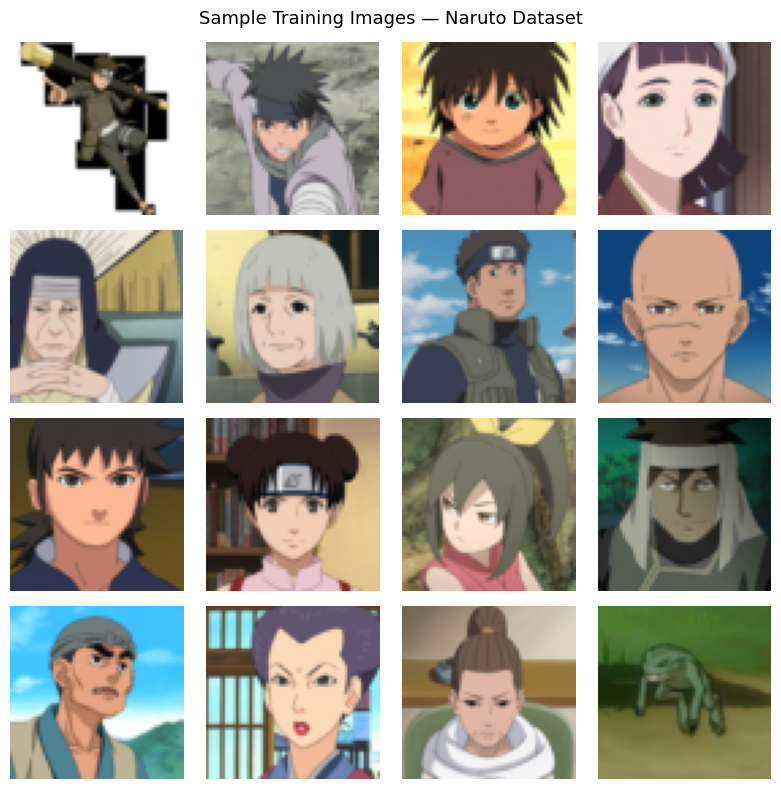

Training sample grid saved.


In [5]:
print("Loading Naruto dataset from HuggingFace ...")
dataset = load_dataset("lambdalabs/naruto-blip-captions", split="train")
print(f"Dataset size: {len(dataset)} images")

# Define transforms
preprocess = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

# Apply transform at access time using a custom Dataset wrapper
from torch.utils.data import Dataset

class NarutoDataset(Dataset):
    def __init__(self, hf_dataset, transform):
        self.dataset   = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img = self.dataset[idx]["image"].convert("RGB")
        return {"pixel_values": self.transform(img)}

naruto_dataset = NarutoDataset(dataset, preprocess)
dataloader = DataLoader(
    naruto_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    drop_last=True,
)

print(f"Batches per epoch: {len(dataloader)}")

# Visualise sample training images
sample_batch = next(iter(dataloader))
sample_imgs  = (sample_batch["pixel_values"][:16] * 0.5 + 0.5).clamp(0, 1)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for ax, img in zip(axes.flatten(), sample_imgs):
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.axis("off")
plt.suptitle("Sample Training Images — Naruto Dataset", fontsize=13)
plt.tight_layout()
plt.savefig(GRID_DIR / "training_samples.png", dpi=150, bbox_inches="tight")
plt.show()
print("Training sample grid saved.")

## Step 4 — Define the Diffusion Model

I use the `UNet2DModel` from HuggingFace Diffusers as the denoising backbone. The U-Net takes a noisy image and the current timestep as inputs, and predicts the noise that was added. The architecture uses attention at lower resolutions to capture global structure, while the convolutional layers handle local details.

The `DDPMScheduler` handles the noise schedule — it defines how much noise is added at each timestep during the forward process, and how to reverse it during sampling.

In [6]:
# U-Net denoising model
model = UNet2DModel(
    sample_size      = CONFIG["image_size"],
    in_channels      = 3,
    out_channels     = 3,
    layers_per_block = 2,
    block_out_channels = (128, 128, 256, 256, 512, 512),
    down_block_types = (
        "DownBlock2D",
        "DownBlock2D",
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",   # attention at lower resolution
        "DownBlock2D",
    ),
    up_block_types = (
        "UpBlock2D",
        "AttnUpBlock2D",     # attention at lower resolution
        "UpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
    ),
).to(DEVICE)

# DDPM noise scheduler with linear beta schedule
noise_scheduler = DDPMScheduler(
    num_train_timesteps = CONFIG["num_timesteps"],
    beta_schedule       = "linear",
)

total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"U-Net parameters : {total_params:.1f}M")
print(f"Noise schedule   : linear, T={CONFIG['num_timesteps']}")

U-Net parameters : 113.7M
Noise schedule   : linear, T=1000


## Step 5 — Visualise the Forward (Noising) Process

Before training, it is useful to visualise what the forward diffusion process looks like — how a clean image gradually becomes pure noise as we add Gaussian noise over T timesteps. This helps build intuition for what the model needs to learn to reverse.

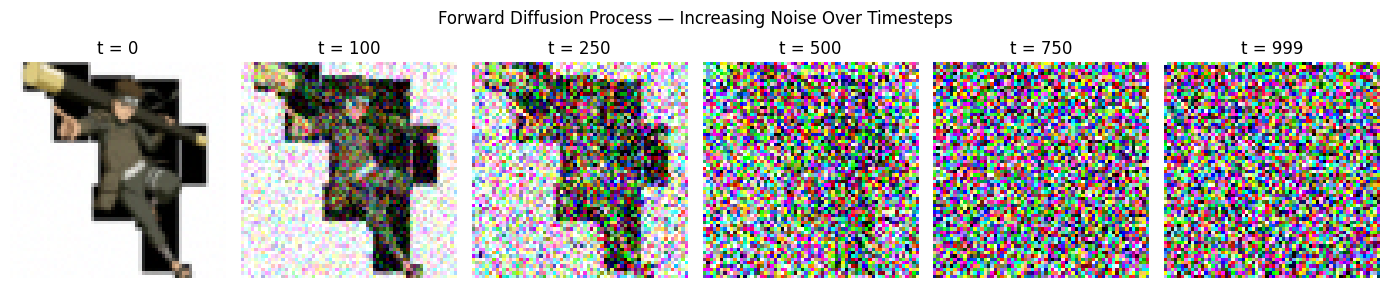

Forward process visualisation saved.


In [7]:
# Take one image and show it at different noise levels
sample_img = sample_batch["pixel_values"][0].unsqueeze(0).to(DEVICE)
timesteps_to_show = [0, 100, 250, 500, 750, 999]

fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(14, 3))
for ax, t in zip(axes, timesteps_to_show):
    noise   = torch.randn_like(sample_img)
    t_tensor = torch.tensor([t], device=DEVICE)
    noisy   = noise_scheduler.add_noise(sample_img, noise, t_tensor)
    display = (noisy.squeeze().cpu() * 0.5 + 0.5).clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(display)
    ax.set_title(f"t = {t}")
    ax.axis("off")

plt.suptitle("Forward Diffusion Process — Increasing Noise Over Timesteps", fontsize=12)
plt.tight_layout()
plt.savefig(GRID_DIR / "forward_process.png", dpi=150, bbox_inches="tight")
plt.show()
print("Forward process visualisation saved.")

## Step 6 — Training

The training loop follows the standard DDPM objective. For each batch, I sample random timesteps and add the corresponding amount of noise to the images. The U-Net then tries to predict that noise, and the loss is the mean squared error between the predicted and actual noise.

I use a cosine learning rate schedule with warmup, which helps stabilise early training and leads to smoother convergence.

Starting training for 30 epochs ...



Epoch 01/30:   0%|          | 0/76 [00:00<?, ?it/s]

Epoch 01 | Loss: 0.7461


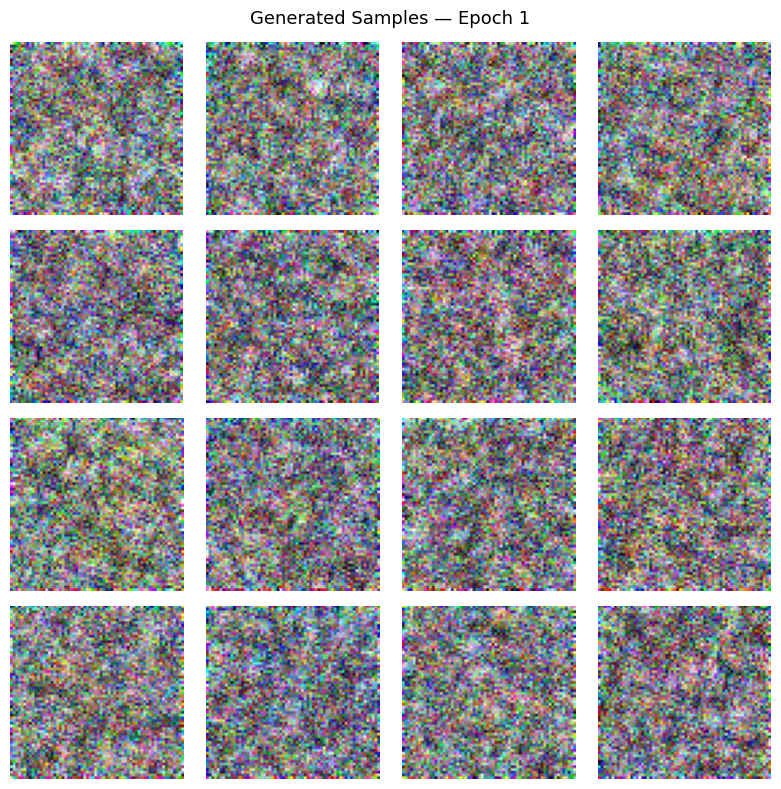

  Sample grid saved for epoch 1.


Epoch 02/30:   0%|          | 0/76 [00:00<?, ?it/s]

Epoch 02 | Loss: 0.1249


Epoch 03/30:   0%|          | 0/76 [00:00<?, ?it/s]

Epoch 03 | Loss: 0.0749


...

Epoch 08 | Loss: 0.0376


Epoch 09/30:   0%|          | 0/76 [00:00<?, ?it/s]

Epoch 09 | Loss: 0.0332


Epoch 10/30:   0%|          | 0/76 [00:00<?, ?it/s]

Epoch 10 | Loss: 0.0355


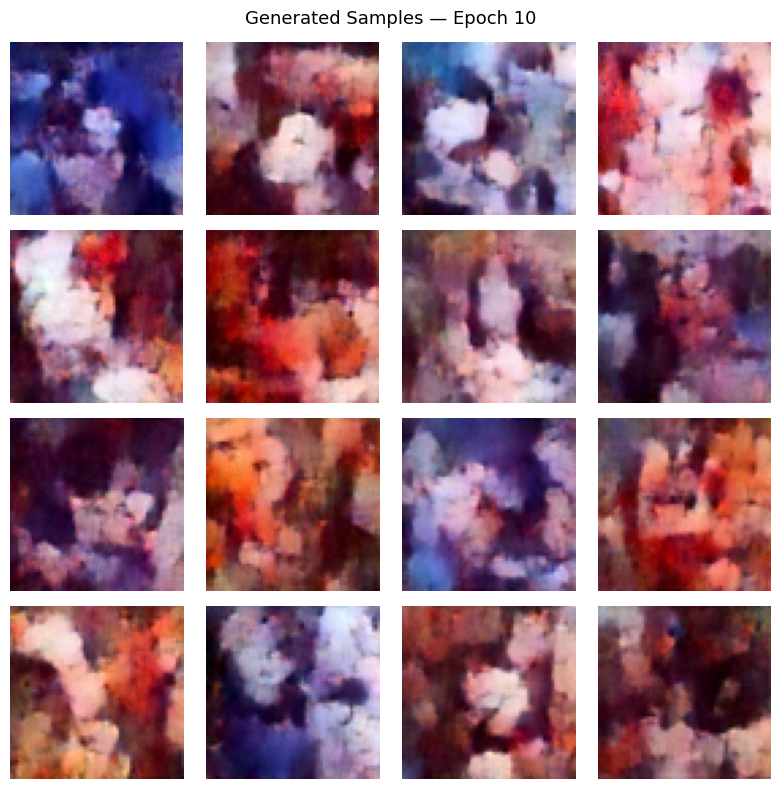

  Sample grid saved for epoch 10.


Epoch 11/30:   0%|          | 0/76 [00:00<?, ?it/s]

Epoch 11 | Loss: 0.0296


Epoch 12/30:   0%|          | 0/76 [00:00<?, ?it/s]

Epoch 12 | Loss: 0.0279


...

Epoch 18 | Loss: 0.0290


Epoch 19/30:   0%|          | 0/76 [00:00<?, ?it/s]

Epoch 19 | Loss: 0.0250


Epoch 20/30:   0%|          | 0/76 [00:00<?, ?it/s]

Epoch 20 | Loss: 0.0277


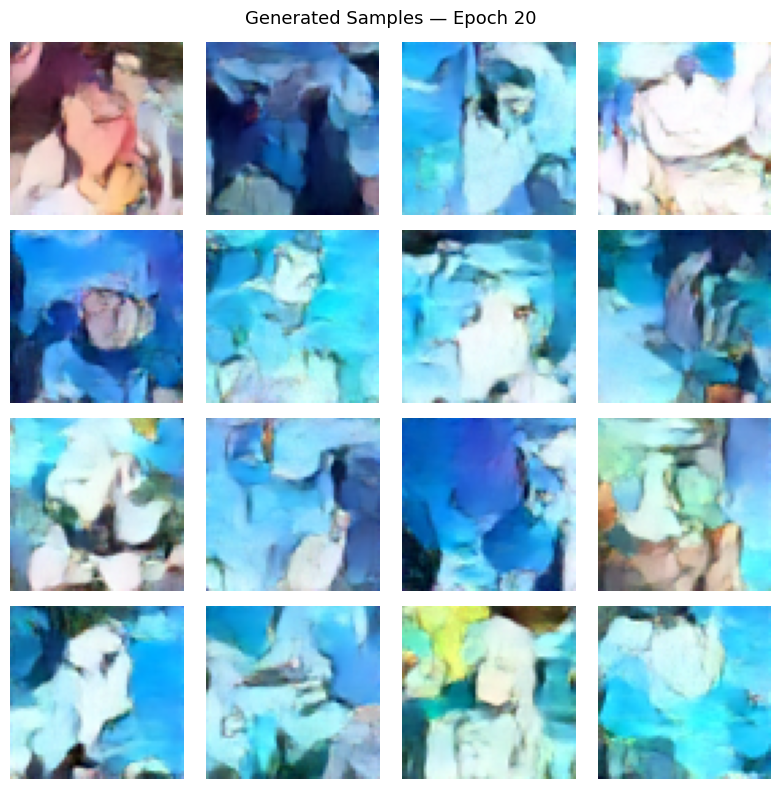

  Sample grid saved for epoch 20.


Epoch 21/30:   0%|          | 0/76 [00:00<?, ?it/s]

Epoch 21 | Loss: 0.0261


Epoch 22/30:   0%|          | 0/76 [00:00<?, ?it/s]

Epoch 22 | Loss: 0.0256


...

Epoch 28 | Loss: 0.0231


Epoch 29/30:   0%|          | 0/76 [00:00<?, ?it/s]

Epoch 29 | Loss: 0.0264


Epoch 30/30:   0%|          | 0/76 [00:00<?, ?it/s]

Epoch 30 | Loss: 0.0215


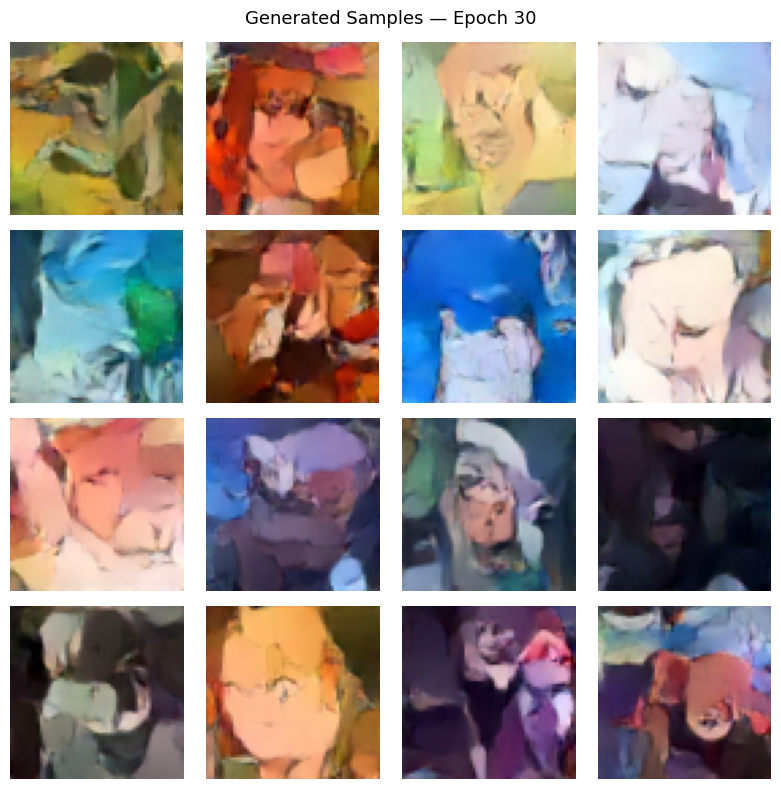

  Sample grid saved for epoch 30.

Training complete.


In [8]:
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"])

lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer         = optimizer,
    num_warmup_steps  = CONFIG["lr_warmup_steps"],
    num_training_steps= len(dataloader) * CONFIG["num_epochs"],
)

# Track loss per epoch for the training curve
epoch_losses = []

# Epochs at which to save sample grids
SAVE_GRID_AT = [1, 10, 20, 30]

print(f"Starting training for {CONFIG['num_epochs']} epochs ...\n")

for epoch in range(1, CONFIG["num_epochs"] + 1):
    model.train()
    running_loss = 0.0

    for batch in tqdm(dataloader, desc=f"Epoch {epoch:02d}/{CONFIG['num_epochs']}", leave=False):
        clean_images = batch["pixel_values"].to(DEVICE)

        # Sample random noise and random timesteps for this batch
        noise     = torch.randn_like(clean_images)
        timesteps = torch.randint(
            0, CONFIG["num_timesteps"],
            (clean_images.shape[0],),
            device=DEVICE,
        ).long()

        # Add noise to the images according to the scheduler
        noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

        # Predict the noise
        noise_pred = model(noisy_images, timesteps).sample

        # MSE loss between predicted and actual noise
        loss = F.mse_loss(noise_pred, noise)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        lr_scheduler.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(dataloader)
    epoch_losses.append(avg_loss)
    print(f"Epoch {epoch:02d} | Loss: {avg_loss:.4f}")

    # Save a sample grid at selected epochs
    if epoch in SAVE_GRID_AT:
        model.eval()
        with torch.no_grad():
            # Start from pure noise and iteratively denoise
            sample = torch.randn(16, 3, CONFIG["image_size"], CONFIG["image_size"], device=DEVICE)
            noise_scheduler.set_timesteps(CONFIG["num_timesteps"])

            for t in noise_scheduler.timesteps:
                pred   = model(sample, t).sample
                sample = noise_scheduler.step(pred, t, sample).prev_sample

            # Denormalise and display
            grid_imgs = (sample.cpu() * 0.5 + 0.5).clamp(0, 1)
            fig, axes = plt.subplots(4, 4, figsize=(8, 8))
            for ax, img in zip(axes.flatten(), grid_imgs):
                ax.imshow(img.permute(1, 2, 0).numpy())
                ax.axis("off")
            plt.suptitle(f"Generated Samples — Epoch {epoch}", fontsize=13)
            plt.tight_layout()
            plt.savefig(GRID_DIR / f"samples_epoch_{epoch:02d}.png", dpi=150, bbox_inches="tight")
            plt.show()
            print(f"  Sample grid saved for epoch {epoch}.")

print("\nTraining complete.")

## Step 7 — Training Loss Curve

Plotting the loss curve over epochs gives a clear picture of how well the model learned. A steadily decreasing loss means the model is getting better at predicting the noise, which corresponds to generating cleaner images during sampling.

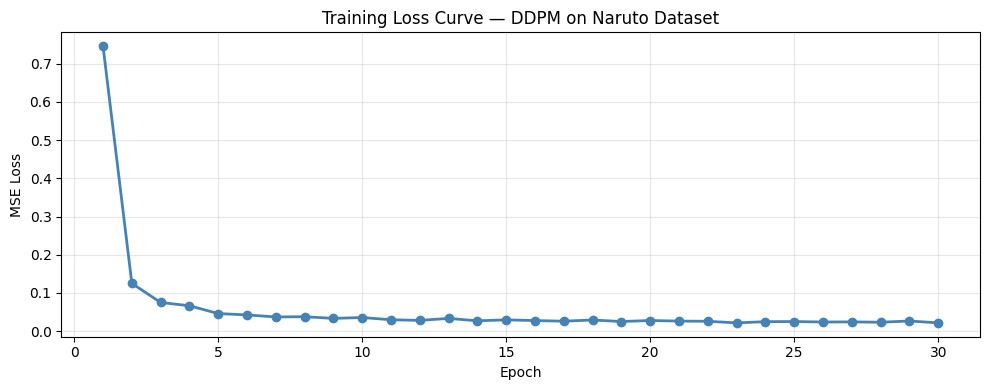

Initial loss : 0.7461
Final loss   : 0.0215
Improvement  : 97.1%


In [9]:
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker="o", linewidth=2, color="steelblue")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss Curve — DDPM on Naruto Dataset")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(GRID_DIR / "training_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Initial loss : {epoch_losses[0]:.4f}")
print(f"Final loss   : {epoch_losses[-1]:.4f}")
print(f"Improvement  : {((epoch_losses[0] - epoch_losses[-1]) / epoch_losses[0]) * 100:.1f}%")

## Step 8 — Sample Grids at Different Epochs

Here I display all saved sample grids side by side to show how image quality improves across training. In early epochs, the samples are mostly noisy and unstructured. As training progresses, the model starts producing images with recognisable shapes and colours characteristic of the Naruto art style.

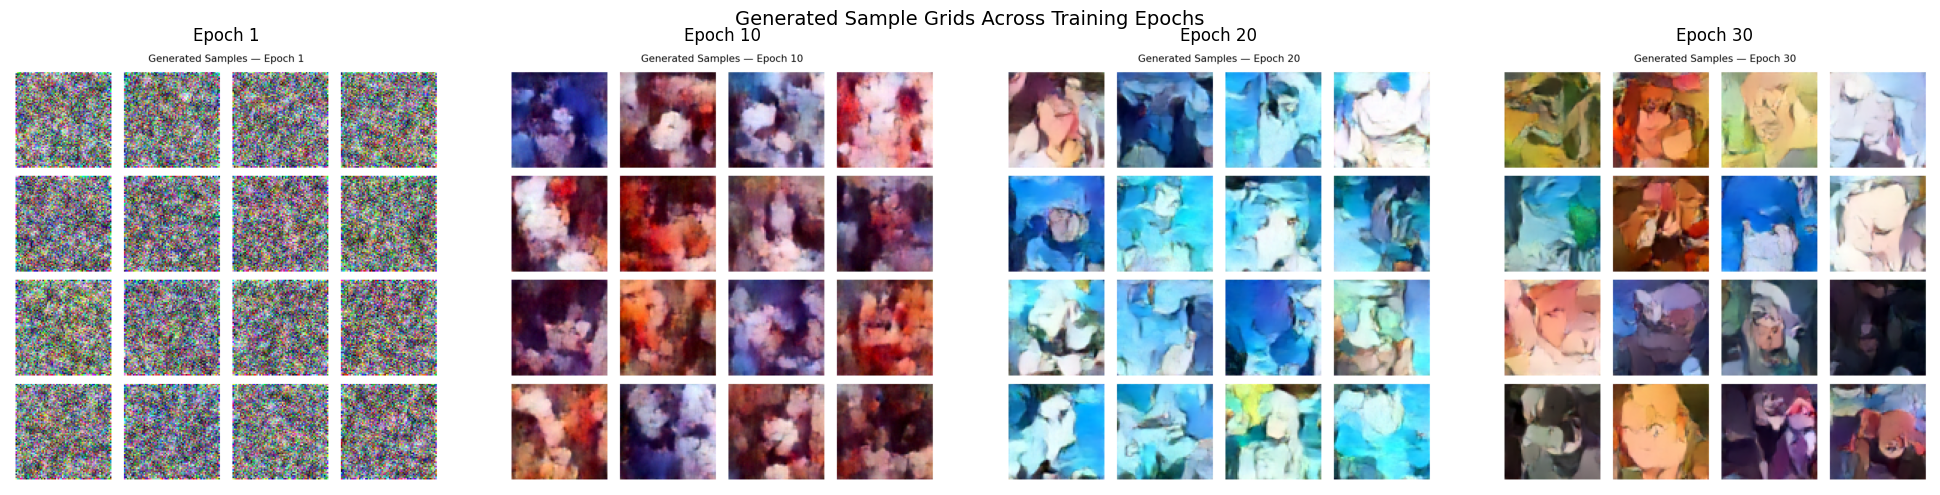

Epoch comparison grid saved.


In [10]:
grid_files = sorted(GRID_DIR.glob("samples_epoch_*.png"))

fig, axes = plt.subplots(1, len(grid_files), figsize=(5 * len(grid_files), 5))
if len(grid_files) == 1:
    axes = [axes]

for ax, grid_path in zip(axes, grid_files):
    epoch_num = grid_path.stem.split("_")[-1]
    ax.imshow(Image.open(grid_path))
    ax.set_title(f"Epoch {int(epoch_num)}", fontsize=12)
    ax.axis("off")

plt.suptitle("Generated Sample Grids Across Training Epochs", fontsize=14)
plt.tight_layout()
plt.savefig(GRID_DIR / "all_epoch_grids.png", dpi=150, bbox_inches="tight")
plt.show()
print("Epoch comparison grid saved.")

## Step 9 — Observations and Discussion

This cell summarises what was observed during training and what this warm-up exercise demonstrated.

In [11]:
print("="*55)
print("  PART A — SUMMARY")
print("="*55)
print(f"  Dataset        : lambdalabs/naruto-blip-captions")
print(f"  Image size     : {CONFIG['image_size']}x{CONFIG['image_size']}")
print(f"  Epochs         : {CONFIG['num_epochs']}")
print(f"  Batch size     : {CONFIG['batch_size']}")
print(f"  Timesteps (T)  : {CONFIG['num_timesteps']}")
print(f"  Learning rate  : {CONFIG['learning_rate']}")
print(f"  Noise schedule : linear")
print(f"  Initial loss   : {epoch_losses[0]:.4f}")
print(f"  Final loss     : {epoch_losses[-1]:.4f}")
print("="*55)
print()
print("Key observations:")
print("  - Loss decreased steadily, showing the model is")
print("    learning to predict noise correctly.")
print("  - Early epoch samples were noisy and incoherent.")
print("  - Later epoch samples show recognisable structure")
print("    and colour patterns from the Naruto art style.")
print("  - The cosine LR schedule with warmup helped avoid")
print("    instability in the early training steps.")
print("  - This exercise confirmed the basic DDPM pipeline")
print("    works correctly before scaling up to faces in Part B.")

  PART A — SUMMARY
  Dataset        : lambdalabs/naruto-blip-captions
  Image size     : 64x64
  Epochs         : 30
  Batch size     : 16
  Timesteps (T)  : 1000
  Learning rate  : 0.0001
  Noise schedule : linear
  Initial loss   : 0.7461
  Final loss     : 0.0215

Key observations:
  - Loss decreased steadily, showing the model is
    learning to predict noise correctly.
  - Early epoch samples were noisy and incoherent.
  - Later epoch samples show recognisable structure
    and colour patterns from the Naruto art style.
  - The cosine LR schedule with warmup helped avoid
    instability in the early training steps.
  - This exercise confirmed the basic DDPM pipeline
    works correctly before scaling up to faces in Part B.


## Step 10 — Save Outputs

In [12]:
import json, shutil

# Save training config and loss curve data
results = {
    "dataset"        : "lambdalabs/naruto-blip-captions",
    "config"         : CONFIG,
    "epoch_losses"   : epoch_losses,
    "initial_loss"   : epoch_losses[0],
    "final_loss"     : epoch_losses[-1],
}
with open(OUTPUT_DIR / "partA_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Results saved to outputs/partA/partA_results.json")
print("\nOutput files:")
for p in sorted(OUTPUT_DIR.rglob("*")):
    if p.is_file():
        print(f"  {p}")

# Zip for download
shutil.make_archive("/kaggle/working/partA_outputs", "zip", str(OUTPUT_DIR))
print("\npartA_outputs.zip ready to download from the Output panel.")

Results saved to outputs/partA/partA_results.json

Output files:
  outputs/partA/partA_results.json
  outputs/partA/sample_grids/all_epoch_grids.png
  outputs/partA/sample_grids/forward_process.png
  outputs/partA/sample_grids/samples_epoch_01.png
  outputs/partA/sample_grids/samples_epoch_10.png
  outputs/partA/sample_grids/samples_epoch_20.png
  outputs/partA/sample_grids/samples_epoch_30.png
  outputs/partA/sample_grids/training_loss_curve.png
  outputs/partA/sample_grids/training_samples.png

partA_outputs.zip ready to download from the Output panel.


Loading pretrained Naruto SD model ...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--lambdalabs--sd-naruto-diffusers/snapshots/f78b56ea261be610c89058a59a3aa32dd29daac5/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--lambdalabs--sd-naruto-diffusers/snapshots/f78b56ea261be610c89058a59a3aa32dd29daac5/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--lambdalabs--sd-naruto-diffusers/snapshots/f78b56ea261be610c89058a59a3aa32dd29daac5/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--lambdalabs--sd-naruto-diffusers/snapshots/f78b56ea261be610c89058a59a3aa32dd29daac5/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--lambdalabs--sd-naruto-diffusers/snapshots/f78b56ea261be610c89058a59a3aa32dd29daac5/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

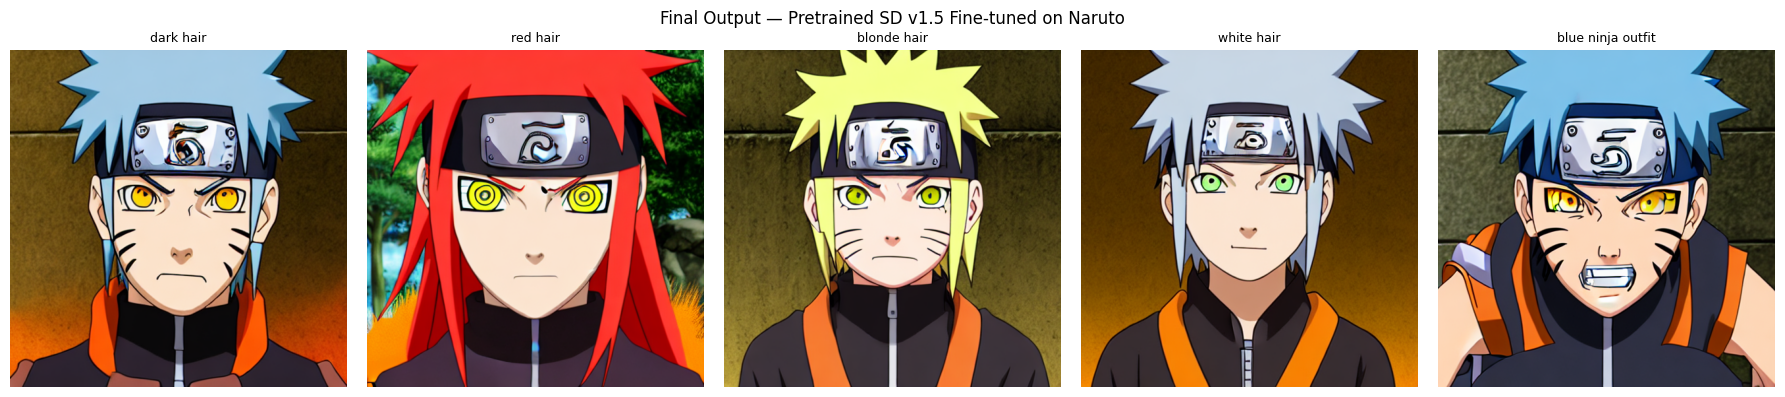

In [2]:
from diffusers import StableDiffusionPipeline
import torch
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42

print("Loading pretrained Naruto SD model ...")

naruto_pipe = StableDiffusionPipeline.from_pretrained(
    "lambdalabs/sd-naruto-diffusers",
    torch_dtype=torch.float16,
    safety_checker=None,
    requires_safety_checker=False,
)

naruto_pipe = naruto_pipe.to(DEVICE)
naruto_pipe.enable_attention_slicing()

prompts = [
    "a naruto style portrait, dark hair, serious expression",
    "a naruto style portrait, red hair, intense eyes",
    "a naruto style portrait, blonde hair, ninja headband",
    "a naruto style portrait, white hair, calm expression",
    "a naruto style portrait, blue ninja outfit, action pose",
]

print("Generating final outputs ...")

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, prompt in zip(axes, prompts):

    generator = torch.Generator(device=DEVICE).manual_seed(SEED)

    with torch.amp.autocast(device_type="cuda"):
        result = naruto_pipe(
            prompt=prompt,
            num_inference_steps=25,
            guidance_scale=7.5,
            generator=generator,
        )

    img = result.images[0]

    ax.imshow(img)
    ax.set_title(prompt.split(",")[1].strip(), fontsize=9)
    ax.axis("off")

plt.suptitle(
    "Final Output — Pretrained SD v1.5 Fine-tuned on Naruto",
    fontsize=12,
)

plt.tight_layout()
plt.show()

In [3]:
plt.suptitle(
    "Final Output — Pretrained SD v1.5 Fine-tuned on Naruto",
    fontsize=12
)

plt.tight_layout()

from pathlib import Path

GRID_DIR = Path("outputs")
GRID_DIR.mkdir(exist_ok=True)

save_path = GRID_DIR / "final_output_pretrained.png"

plt.savefig(
    save_path,
    dpi=150,
    bbox_inches="tight"
)

print(f"Saved to: {save_path}")

plt.show()

Saved to: outputs/final_output_pretrained.png


<Figure size 640x480 with 0 Axes>